# NovaFinds E-commerce Data Pipeline

## Medallion Architecture Overview

This notebook implements a **three-layer medallion architecture** for NovaFinds e-commerce data:

### 🥉 Bronze Layer (Raw Data Ingestion)
- **Purpose**: Ingest raw CSV files from Unity Catalog Volume
- **Tables**: `*_bronze` tables (customer, product, orders, payment, etc.)
- **Characteristics**: Minimal transformation, preserve raw data, include `_rescued_data` for malformed records

### 🥈 Silver Layer (Cleaned & Enriched)
- **Purpose**: Clean, validate, and join related tables
- **Tables**: `*_silver` tables with business logic applied
- **Transformations**: Remove invalid records, join dimensions, add calculated fields

### 🥇 Gold Layer (Business-Level Aggregates)
- **Purpose**: Create aggregated tables optimized for analytics and reporting
- **Tables**: `*_gold` tables with KPIs and metrics
- **Use Cases**: Product profitability, cancellation analysis, regional sales

---

In [0]:
%sql
USE CATALOG main;
CREATE SCHEMA IF NOT EXISTS novafinds;
USE SCHEMA novafinds;
CREATE VOLUME IF NOT EXISTS postgres;

In [0]:
spark.sql(f"LIST '/Volumes/main/novafinds/postgres/' ").display()

path,name,size,modification_time
/Volumes/main/novafinds/postgres/address.csv,address.csv,4922,1775805191000
/Volumes/main/novafinds/postgres/brand.csv,brand.csv,159,1775805191000
/Volumes/main/novafinds/postgres/customer.csv,customer.csv,12827,1775805191000
/Volumes/main/novafinds/postgres/customer_type.csv,customer_type.csv,99,1775805191000
/Volumes/main/novafinds/postgres/order_item.csv,order_item.csv,13642,1775805191000
/Volumes/main/novafinds/postgres/orders.csv,orders.csv,31926,1775805191000
/Volumes/main/novafinds/postgres/payment.csv,payment.csv,100969,1775805191000
/Volumes/main/novafinds/postgres/payment_method.csv,payment_method.csv,71,1775805191000
/Volumes/main/novafinds/postgres/product.csv,product.csv,8219,1775805191000
/Volumes/main/novafinds/postgres/product_category.csv,product_category.csv,471,1775805191000


## 🥉 Bronze Layer: Raw Data Ingestion

**Objective**: Load raw CSV files from the Unity Catalog Volume into Delta tables with minimal transformation.

**Source**: `/Volumes/main/novafinds/postgres/` - PostgreSQL export files

**Process**:
1. Scan volume for all CSV files
2. Create one bronze table per CSV file
3. Use `read_files()` with schema inference
4. Preserve `_rescued_data` column for data quality monitoring

**Tables Created**: address_bronze, brand_bronze, customer_bronze, customer_type_bronze, order_item_bronze, orders_bronze, payment_bronze, payment_method_bronze, product_bronze, product_category_bronze

In [0]:
import os
from datetime import datetime

# Bronze Layer: Automated CSV to Delta Table Ingestion
# Scans the volume directory and creates one bronze table per CSV file

volume_path = '/Volumes/main/novafinds/postgres/'
print(f"⏳ Starting bronze layer ingestion from: {volume_path}\n")
print("=" * 70)

# List all CSV files in the directory
files = [f for f in os.listdir(volume_path) if f.endswith('.csv')]
print(f"\n📁 Found {len(files)} CSV files to process\n")

# Process each CSV file
created_tables = []
for idx, file in enumerate(files, 1):
    table_name = os.path.splitext(file)[0] + '_bronze'
    
    print(f"[{idx}/{len(files)}] Processing: {file} → {table_name}")
    
    try:
        # Drop existing table to ensure clean state
        spark.sql(f"DROP TABLE IF EXISTS {table_name}")
        
        # Create bronze table from CSV with schema inference
        spark.sql(f"""
            CREATE TABLE {table_name}
            AS
            SELECT * 
            FROM read_files(
              '{volume_path}{file}',
              format => 'csv',
              header => true,
              inferSchema => true
            )
        """)
        
        # Get row count for validation
        row_count = spark.sql(f"SELECT COUNT(*) as cnt FROM {table_name}").collect()[0]['cnt']
        created_tables.append((table_name, row_count))
        print(f"     ✅ Created: {row_count:,} rows\n")
        
    except Exception as e:
        print(f"     ❌ Error: {str(e)}\n")

print("=" * 70)
print(f"\n✅ Bronze layer ingestion complete!")
print(f"\nCreated {len(created_tables)} tables:")
for table, rows in created_tables:
    print(f"  - {table}: {rows:,} rows")

# Display all tables in the schema
print("\n" + "=" * 70)
print("\n📊 All tables in schema:\n")
display(spark.sql('SHOW TABLES'))

⏳ Starting bronze layer ingestion from: /Volumes/main/novafinds/postgres/


📁 Found 10 CSV files to process

[1/10] Processing: address.csv → address_bronze
     ✅ Created: 100 rows

[2/10] Processing: brand.csv → brand_bronze
     ✅ Created: 12 rows

[3/10] Processing: customer.csv → customer_bronze
     ✅ Created: 100 rows

[4/10] Processing: customer_type.csv → customer_type_bronze
     ✅ Created: 7 rows

[5/10] Processing: order_item.csv → order_item_bronze
     ✅ Created: 1,000 rows

[6/10] Processing: orders.csv → orders_bronze
     ✅ Created: 500 rows

[7/10] Processing: payment.csv → payment_bronze
     ✅ Created: 520 rows

[8/10] Processing: payment_method.csv → payment_method_bronze
     ✅ Created: 3 rows

[9/10] Processing: product.csv → product_bronze
     ✅ Created: 100 rows

[10/10] Processing: product_category.csv → product_category_bronze
     ✅ Created: 24 rows


✅ Bronze layer ingestion complete!

Created 10 tables:
  - address_bronze: 100 rows
  - brand_bronze: 12 ro

database,tableName,isTemporary
novafinds,address_bronze,false
novafinds,brand_bronze,false
novafinds,cancelled_product_gold,false
novafinds,customer_bronze,false
novafinds,customer_silver,false
novafinds,customer_type_bronze,false
novafinds,order_item_bronze,false
novafinds,order_silver,false
novafinds,orders_bronze,false
novafinds,orders_silver,false


In [0]:
%sql
CREATE TABLE IF NOT EXISTS stripe_payments AS
SELECT * 
FROM read_files(
  '/Volumes/main/novafinds/stripe/20251230_stripe_payments.json',
  format => 'JSON',
  multiLine => true
);

SELECT data from stripe_payments limit 5

data


## 🥈 Silver Layer: Cleaned & Enriched Data

**Objective**: Join related tables, apply data quality rules, and create analytics-ready datasets.

**Transformations**:
- **Joins**: Combine fact tables with dimension tables (products + categories + brands, customers + types + addresses, orders + items + payments)
- **Filtering**: Remove inactive products, validate records
- **Enrichment**: Add calculated fields (e.g., `is_correct` flag for customer validation)
- **Cleanup**: Exclude `_rescued_data` column from final tables

**Tables Created**: 
- `product_silver` - Products with category and brand names
- `customer_silver` - Customers with type and location
- `order_silver` - Orders with line items and payment amounts
- `payment_silver` - Payments with method names

In [0]:
%sql
-- Product Silver Table: Enrich products with category and brand information
-- Filter: Only include active products (is_active = true)
-- Join: Product category and brand dimensions

CREATE OR REPLACE TABLE product_silver AS
SELECT 
  p.* EXCEPT (_rescued_data),
  pc.category_name,
  b.brand_name
FROM product_bronze p
JOIN product_category_bronze pc
  ON pc.product_category_id = p.product_category_id
JOIN brand_bronze b
  ON b.brand_id = p.brand_id
WHERE p.is_active = true;

SELECT * FROM product_silver LIMIT 10

product_id,product_name,sku,price,is_active,brand_id,product_category_id,category_name,brand_name
1,Elegant Maxi Skirt,68cbcedeb5bd4133dff5af2e621b17be33a818c9,44.99,true,5,2,Electronics,Cloudory
2,Creamy Coleslaw Mix,3dffd43b0d261019a51ea0e90ccbed4d358ecf97,2.39,true,12,4,Tools & Hardware,Virexia
3,Sweetened Condensed Milk,fc35268a3add96ae3254c094c4eadb1a5aee12cc,1.89,true,11,22,Music Instruments,Klyra
4,Maple Almond Yogurt,5a1e2cd2e7f47c97a8acfe2b92eb9dfb5bc8dfea,1.89,true,2,10,Office Supplies,LumoPeak
6,Almond Butter Crunch Bar,beb180784e163c16fb24fa2d24be6e289bd16887,1.99,true,1,14,Watches,Mintara
8,Smart Doorbell,dc5157cd0822cea83575b22142a7350ae8369516,119.99,true,11,2,Electronics,Klyra
9,Silicone Stretch Lids,f7f523547fb5be2a3b890b1cedca951420019fea,14.99,true,11,22,Music Instruments,Klyra
10,Organic Green Lentils,14da9927a39d86b6ce213a2fe7eeb0766e8e7cdd,3.99,true,5,16,Travel & Luggage,Cloudory
12,Sunglasses Case,e4ae1d3ee932b7598d253c04f757af9b2dfff30d,15.99,true,10,5,Sports & Outdoors,UrbanFox
13,Spicy Vegetable Sushi Rolls,9af85c40d8b607076ca142f91939d9cd0a268a09,8.49,true,4,19,Baby & Kids,Avenly


In [0]:
%sql
-- Customer Silver Table: Enrich customers with type and address information
-- Join: Customer type dimension and address dimension (LEFT JOIN to preserve customers without addresses)
-- Data Quality: Add active_status_is_correct flag to identify mismatches between is_active and type_name
--   - Flag as FALSE if customer is active but type is 'inactive'
--   - Flag as FALSE if customer is inactive but type is 'active'

CREATE OR REPLACE TABLE customer_silver AS
SELECT 
  c.* EXCEPT (_rescued_data),
  ct.type_name,
  a.city,
  a.country,
  CASE 
    WHEN c.is_active IS true AND ct.type_name = 'inactive' THEN false
    WHEN c.is_active IS false AND ct.type_name = 'active' THEN false
    ELSE true
  END as active_status_is_correct
FROM customer_bronze c
JOIN customer_type_bronze ct
  ON ct.customer_type_id = c.customer_type_id
LEFT JOIN address_bronze a
  ON a.customer_id = c.customer_id;

SELECT * FROM customer_silver LIMIT 10

customer_id,email,password_hash,first_name,last_name,phone,created_at,last_login,is_active,customer_type_id,type_name,city,country,active_status_is_correct
1,pmaystone0@youtube.com,e1aa982447425de077a37c41e0b28d65120026be,Pierrette,Maystone,+33 887 859 0688,2025-07-18T08:09:24.000Z,null,false,4,guest,Malabonot,PH,true
2,nhatchette1@theguardian.com,7e9a6cf162446b741a01e4d09f013a613ceae9a3,Nancey,Hatchette,+963 158 686 4231,2025-06-19T04:44:11.000Z,null,true,6,recurring,Tonj,SS,true
52,smcblain1f@fotki.com,ef03aa4587e131a4b03169870c2e64e19c6916f1,Sayres,McBlain,null,2025-07-08T00:10:50.000Z,null,false,5,other,null,null,true
3,fhatherley2@webeden.co.uk,0ca65738cdaba0e67b902b753bd9636cb969b8bd,Filberto,Hatherley,+63 538 568 2480,2025-08-25T17:31:13.000Z,null,false,2,active,Youchou,CN,false
4,rfolshom3@phpbb.com,f68077050729e87a8b749075566b8b67be7b8e8a,Raye,Folshom,+351 180 298 1488,2025-12-15T10:59:29.000Z,null,false,2,active,null,null,false
5,vkarlolak4@mapy.cz,9795887b9e9d2c1ba74bec419c11852c199cafba,Virginia,Karlolak,+968 321 171 4955,2025-04-25T13:59:07.000Z,null,true,6,recurring,Cácota,CO,true
6,mcramb5@gravatar.com,4937300be5f785a7871cca621dd0eb55e2cb730a,Mehetabel,Cramb,+56 846 193 7633,2025-04-22T15:13:41.000Z,null,false,2,active,Oliveira,PT,false
7,gpawlick6@ameblo.jp,e0e9cbe4ca380887816f78732d77a9c10b6b3194,Gail,Pawlick,+62 501 699 2576,2025-07-06T21:03:19.000Z,null,true,5,other,Gadingrejo,ID,true
8,nakister7@example.com,dfb58bd901d71673a873f6b2404574ec5fe2f5dd,Nicholas,Akister,+62 386 461 7158,2025-02-16T06:10:54.000Z,null,true,1,inactive,Jaciara,BR,false
9,shelwig8@boston.com,f38a6608d146ffd3ac52daaa4f6b8e5812710fd6,Sammy,Helwig,+593 416 846 0906,2025-08-25T23:32:56.000Z,null,false,5,other,Guaporé,BR,true


In [0]:
%sql


-- Order Silver Table: Combine orders with line items and payment information
-- Join with product_silver to get product_name for analytics
-- Add unified_amount and unified_currency columns (convert to USD)

CREATE OR REPLACE TABLE order_silver AS
SELECT 
  o.order_id,
  o.customer_id,
  o.shipping_address_id,
  o.order_date,
  o.order_status,
  o.subtotal,
  o.discount_amount,
  o.total_amount,
  o.currency,
  oi.product_id,
  p.product_name,  -- Added from product_silver
  oi.quantity,
  -- Convert total_amount to USD using static FX rates
  CASE
    WHEN o.currency = 'Yuan Renminbi' THEN o.total_amount * 0.1465
    WHEN o.currency = 'Euro' THEN o.total_amount * 1.08
    WHEN o.currency = 'GBP' THEN o.total_amount * 1.25
    WHEN o.currency = 'USD' THEN o.total_amount
    WHEN o.currency = 'Zloty' THEN o.total_amount * 0.25
    WHEN o.currency = 'Yen' THEN o.total_amount * 0.0067
    WHEN o.currency = 'Won' THEN o.total_amount * 0.00075
    WHEN o.currency = 'Tugrik' THEN o.total_amount * 0.00029
    WHEN o.currency = 'Tenge' THEN o.total_amount * 0.0022
    WHEN o.currency = 'Tala' THEN o.total_amount * 0.37
    WHEN o.currency = 'Taka' THEN o.total_amount * 0.0091
    WHEN o.currency = 'Som' THEN o.total_amount * 0.011
    WHEN o.currency = 'Sol' THEN o.total_amount * 0.27
    WHEN o.currency = 'Shilling' THEN o.total_amount * 0.027
    WHEN o.currency = 'Shekel' THEN o.total_amount * 0.27
    WHEN o.currency = 'Rupiah' THEN o.total_amount * 0.000063
    WHEN o.currency = 'Rupee' THEN o.total_amount * 0.012
    WHEN o.currency = 'Ruble' THEN o.total_amount * 0.011
    WHEN o.currency = 'Ringgit' THEN o.total_amount * 0.21
    WHEN o.currency = 'Rial' THEN o.total_amount * 0.0026
    WHEN o.currency = 'Real' THEN o.total_amount * 0.20
    WHEN o.currency = 'Rand' THEN o.total_amount * 0.054
    WHEN o.currency = 'Quetzal' THEN o.total_amount * 0.13
    WHEN o.currency = 'Pula' THEN o.total_amount * 0.073
    WHEN o.currency = 'Pound' THEN o.total_amount * 1.25
    WHEN o.currency = 'Peso' THEN o.total_amount * 0.055
    WHEN o.currency = 'Nakfa' THEN o.total_amount * 0.066
    WHEN o.currency = 'Naira' THEN o.total_amount * 0.00067
    WHEN o.currency = 'Metical' THEN o.total_amount * 0.016
    WHEN o.currency = 'Litas' THEN o.total_amount * 0.29
    WHEN o.currency = 'Lev' THEN o.total_amount * 0.56
    WHEN o.currency = 'Leone' THEN o.total_amount * 0.000052
    WHEN o.currency = 'Lempira' THEN o.total_amount * 0.040
    WHEN o.currency = 'Lek' THEN o.total_amount * 0.011
    WHEN o.currency = 'Kwacha' THEN o.total_amount * 0.055
    WHEN o.currency = 'Kuna' THEN o.total_amount * 0.14
    WHEN o.currency = 'Krone' THEN o.total_amount * 0.091
    WHEN o.currency = 'Krona' THEN o.total_amount * 0.091
    WHEN o.currency = 'Koruna' THEN o.total_amount * 0.043
    WHEN o.currency = 'Hryvnia' THEN o.total_amount * 0.027
    WHEN o.currency = 'Guarani' THEN o.total_amount * 0.00014
    WHEN o.currency = 'Gourde' THEN o.total_amount * 0.0077
    WHEN o.currency = 'Franc' THEN o.total_amount * 0.0011
    WHEN o.currency = 'Escudo' THEN o.total_amount * 0.0098
    WHEN o.currency = 'Dram' THEN o.total_amount * 0.0026
    WHEN o.currency = 'Dong' THEN o.total_amount * 0.000040
    WHEN o.currency = 'Dollar' THEN o.total_amount
    WHEN o.currency = 'Dirham' THEN o.total_amount * 0.27
    WHEN o.currency = 'Dinar' THEN o.total_amount * 3.25
    WHEN o.currency = 'Dalasi' THEN o.total_amount * 0.016
    WHEN o.currency = 'Boliviano' THEN o.total_amount * 0.14
    WHEN o.currency = 'Bolivar' THEN o.total_amount * 0.000028
    WHEN o.currency = 'Balboa' THEN o.total_amount
    WHEN o.currency = 'Baht' THEN o.total_amount * 0.027
    WHEN o.currency = 'Ariary' THEN o.total_amount * 0.00022
    WHEN o.currency = 'Afghani' THEN o.total_amount * 0.014
    ELSE NULL
  END AS unified_amount,
  'USD' AS unified_currency
FROM orders_bronze o
LEFT JOIN order_item_bronze oi
  ON o.order_id = oi.order_id
LEFT JOIN product_silver p
  ON oi.product_id = p.product_id;

SELECT * FROM order_silver LIMIT 10

order_id,customer_id,shipping_address_id,order_date,order_status,subtotal,discount_amount,total_amount,currency,product_id,product_name,quantity,unified_amount,unified_currency
1,7,99,2025-08-05T05:47:28.000Z,processed,771.14,null,516.97,Real,75,Organic Black Bean Burger,2,103.394,USD
2,11,53,2025-09-23T14:50:36.000Z,delivered,548.34,null,409.07,Dollar,79,Quinoa and Kale Salad Kit,1,409.07,USD
3,52,57,2025-07-29T21:30:15.000Z,delivered,970.42,null,733.62,Yuan Renminbi,16,Ice Cube Tray with Lid,2,107.47533,USD
4,47,51,2025-04-28T07:49:28.000Z,delivered,798.41,null,652.55,Yuan Renminbi,90,Honey Butter Popcorn,1,95.59857499999998,USD
5,94,80,2025-08-18T17:56:51.000Z,delivered,791.28,null,132.27,Yuan Renminbi,55,Organic Black Rice,3,19.377555,USD
6,78,62,2025-10-25T17:39:14.000Z,delivered,645.4,96.74,237.69,Baht,16,Ice Cube Tray with Lid,1,6.41763,USD
7,17,74,2025-06-25T21:14:20.000Z,shipped,584.55,null,989.82,Real,88,Tattoo Kit,1,197.96400000000003,USD
9,2,100,2025-02-21T14:45:29.000Z,delivered,48.84,3.89,569.03,Yuan Renminbi,20,Tomato Basil Pasta Sauce,1,83.362895,USD
10,73,31,2025-12-28T06:13:04.000Z,completed,708.57,null,426.06,Euro,28,Travel Laundry Bag,3,460.14480000000003,USD
12,60,51,2025-02-06T12:00:27.000Z,completed,32.78,null,90.88,Ruble,90,Honey Butter Popcorn,2,0.9996799999999999,USD


In [0]:
%sql
-- Payment Silver Table: Enrich payments with payment method names
-- Join: Payment method dimension

CREATE OR REPLACE TABLE payment_silver AS
SELECT 
  p.*,
  pm.method_name
FROM payment_bronze p
JOIN payment_method_bronze pm
  ON pm.payment_method_id = p.payment_method_id;


SELECT * FROM payment_silver LIMIT 10

payment_id,order_id,amount,transaction_id,payment_date,payment_method_id,stripe_payment_id,stripe_status,stripe_created_timestamp,stripe_currency,stripe_customer_id,stripe_payment_method,stripe_payment_method_types,stripe_receipt_email,stripe_description,stripe_latest_charge,stripe_last_payment_error,stripe_cancellation_reason,stripe_canceled_at,stripe_metadata,stripe_raw_response,stripe_sync_timestamp,stripe_hash,_rescued_data,method_name
20,119,339.14,24ac0210de8c9a1c02b8b6eb64e286b4a1bab5758910b4e4da30e13fdece03da,2025-12-31T09:45:34.756Z,2,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,2026-04-09T19:43:15.025Z,null,null,credit card
21,194,421.18,96c4adb52157881fcedf1a14525e7b98f92127d0ce35d5967939c2af3eeada36,2025-12-31T09:45:34.756Z,3,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,2026-04-09T19:43:15.025Z,null,null,debit card
22,268,187.78,a83342ddd6a249550e0b2e32ccb1ed47db0028d97815bbb45a97a4c7603cfcf7,2025-12-31T09:45:34.756Z,3,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,2026-04-09T19:43:15.025Z,null,null,debit card
23,271,403.51,7b00ea0b8cd506dfe0efb10739ca0b22be4e65a38a61e71fe135600c46b0127d,2025-12-31T09:45:34.756Z,2,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,2026-04-09T19:43:15.025Z,null,null,credit card
24,45,79.09,ed44ad89f0f6df177eb1cca88e5c8f2580e4397e133e25d212652d9cfbb839e3,2025-12-31T09:45:34.756Z,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,2026-04-09T19:43:15.025Z,null,null,voucher
25,76,514.78,1a3cb545c83663f4b50c9d0063918a468e87f1956cfba41ae1493c951131a70b,2025-12-31T09:45:34.756Z,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,2026-04-09T19:43:15.025Z,null,null,voucher
26,311,942.22,6f9ffedacc23e5dd8c16b34362db49540ffad9632df9320dee6740f36d898717,2025-12-31T09:45:34.756Z,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,2026-04-09T19:43:15.025Z,null,null,voucher
27,249,347.38,6328b842d620506404e179884692edd13c1894c27fbd0f0c2c0db1ed243842e2,2025-12-31T09:45:34.756Z,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,2026-04-09T19:43:15.025Z,null,null,voucher
28,323,940.64,c32a71a8f7fafbc48aa3031debd28ce000cf50cf9755faacabb63272a8bccb65,2025-12-31T09:45:34.756Z,2,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,2026-04-09T19:43:15.025Z,null,null,credit card
29,451,224.87,17ef11f5da8d3904c4a3f3234df4be9ec7bdbc7a09b8fd30ba6e915d7f974d5d,2025-12-31T09:45:34.756Z,3,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,2026-04-09T19:43:15.025Z,null,null,debit card


## 🥇 Gold Layer: Business Metrics & Analytics

**Objective**: Create aggregated, business-ready tables for dashboards and reporting.

**Analytics Tables**:

### 1. Product Profitability Analysis (`product_profit_gold`)
- **Metrics**: Total profit, unit profit, profit margin by product
- **Dimensions**: Product category, product name
- **Use Case**: Identify most/least profitable products, pricing optimization

### 2. Product Cancellation Analysis (`cancelled_product_gold`)
- **Metrics**: Cancellation rate, cancelled vs non-cancelled order counts
- **Use Case**: Quality issues, customer satisfaction analysis

### 3. Regional Sales Analysis (`sales_region_gold`, `sales_country_gold`)
- **Metrics**: Total sales by region and country
- **Dimensions**: Geographic regions (APAC, EMEA, LATAM, North America)
- **Use Case**: Market performance, expansion opportunities

In [0]:
%sql
-- Product Revenue Analysis (Gold Layer)
-- Purpose: Estimate revenue per product based on related orders
-- 
-- Metrics:
--   - related_revenue: Sum of unified_amount from orders where product_id occurred
--   - total_quantity: Units sold
--   - total_cost: Product cost (price * quantity)
--
-- Use Cases:
--   - Estimate product revenue from orders
--   - Product portfolio analysis

CREATE OR REPLACE TABLE product_revenue_gold AS (
SELECT 
  p.product_id, 
  p.product_name, 
  p.category_name,
  p.price,
  SUM(o.quantity) AS total_quantity,
  SUM(o.quantity * p.price) AS total_cost,
  SUM(o.unified_amount) AS related_revenue
FROM product_silver p
JOIN order_silver o
  ON p.product_id = o.product_id
GROUP BY p.category_name, p.product_id, p.product_name, p.price
);

-- Preview: Top 10 products by related revenue
SELECT * FROM product_revenue_gold ORDER BY related_revenue DESC LIMIT 10

product_id,product_name,category_name,price,total_quantity,total_cost,related_revenue
22,Pet Travel Carrier,Jewelry,39.99,26,1039.74,5527.224660999999
44,Multi-Port USB Hub,Furniture,19.99,20,399.80000000000007,4778.51201
39,Protein Pancake Mix,Books & Media,3.99,24,95.75999999999999,4711.5528055
36,Frozen Salmon Filets,Grocery & Gourmet,12.99,34,441.6600000000001,4522.94422768
57,Magnetic Screen Door,Automotive,24.99,33,824.6700000000002,3947.1844050000004
98,Watering Can with Nozzle,Electronics,19.99,21,419.7900000000001,3881.1549540000005
49,Spicy Snack Mix,Jewelry,4.99,20,99.8,3805.540406320001
6,Almond Butter Crunch Bar,Watches,1.99,18,35.81999999999999,3263.1923450000004
3,Sweetened Condensed Milk,Music Instruments,1.89,17,32.13,2816.19116308
56,Mini Air Purifier,Health & Wellness,49.99,23,1149.77,2758.7572308900003


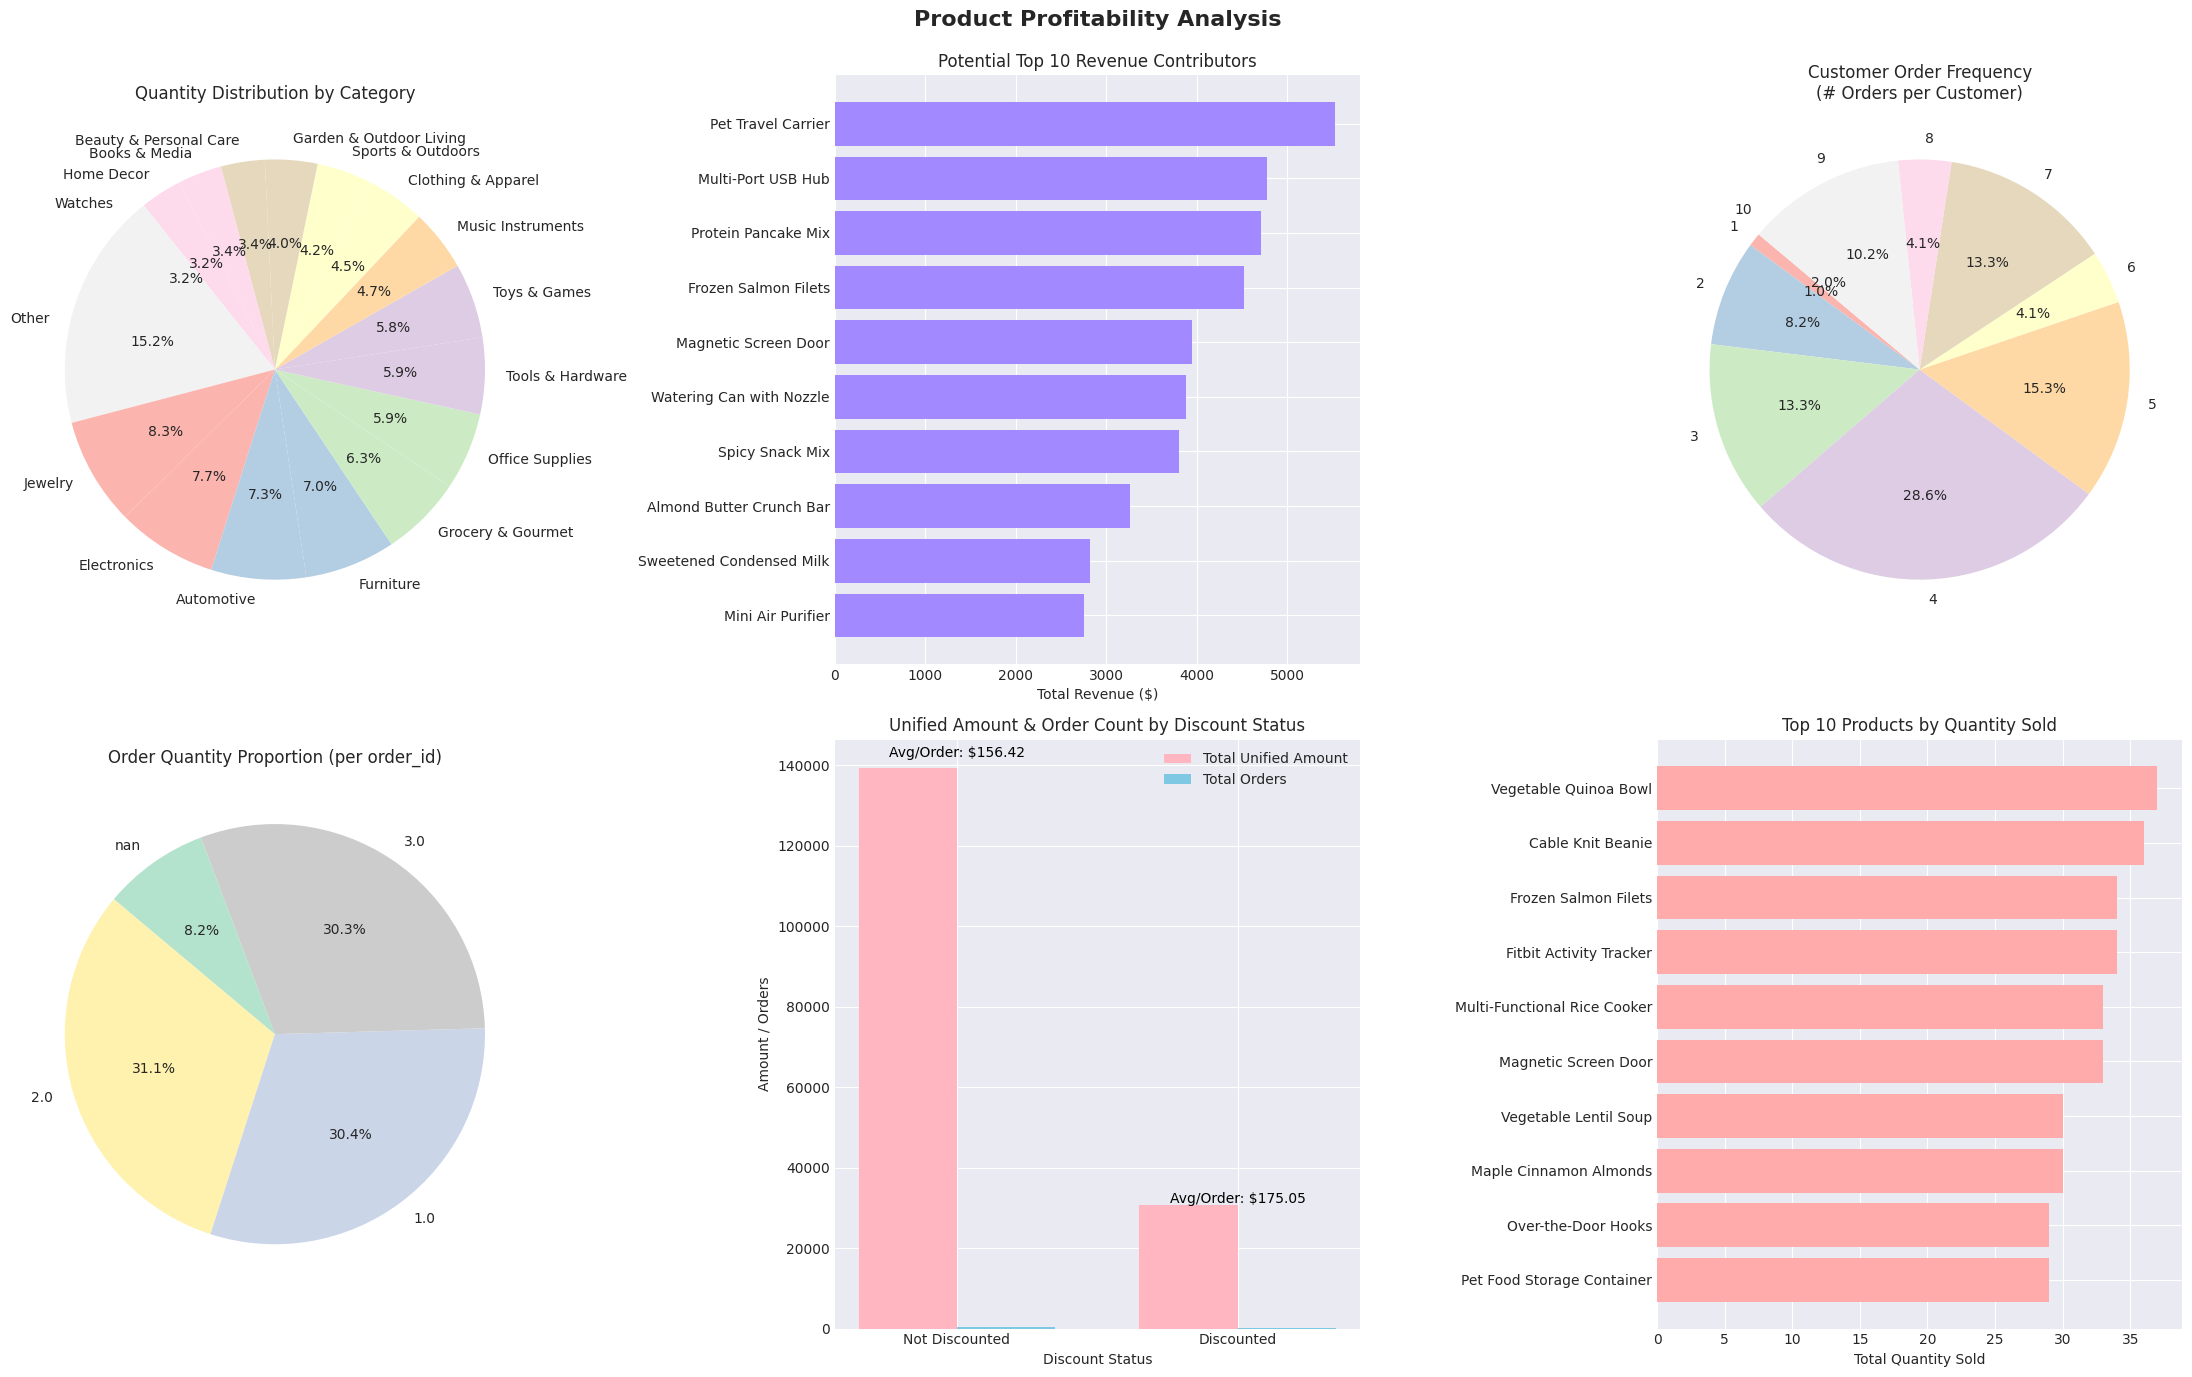


📊 Summary Statistics:
Total Categories: 24


In [0]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-darkgrid')

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Product Profitability Analysis', fontsize=16, fontweight='bold')

# ===== 1. Total Quantity by Category (Pie Chart) =====
df_category_qty = spark.sql("""
    SELECT category_name, SUM(total_quantity) AS total_quantity
    FROM product_revenue_gold
    GROUP BY category_name
    ORDER BY total_quantity DESC
""").toPandas()

threshold_qty = 0.03 * df_category_qty['total_quantity'].sum()
main_cats_qty = df_category_qty[df_category_qty['total_quantity'] >= threshold_qty]
other_cats_qty = df_category_qty[df_category_qty['total_quantity'] < threshold_qty]
if not other_cats_qty.empty:
    main_cats_qty = pd.concat([
        main_cats_qty,
        pd.DataFrame([{
            'category_name': 'Other',
            'total_quantity': other_cats_qty['total_quantity'].sum()
        }])
    ], ignore_index=True)

sorted_idx_qty = np.argsort(-main_cats_qty['total_quantity'])
n_qty = len(main_cats_qty)
colors_qty = [plt.cm.Pastel1(i/max(1, n_qty-1)) for i in range(n_qty)]

axes[0, 0].pie(
    main_cats_qty['total_quantity'].iloc[sorted_idx_qty], 
    labels=main_cats_qty['category_name'].iloc[sorted_idx_qty], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=[colors_qty[i] for i in sorted_idx_qty]
)
axes[0, 0].set_title('Quantity Distribution by Category')

# ===== 2. Highest Revenue per Product (Bar Chart) =====
top_product_revenue = spark.sql("""
    SELECT product_name, related_revenue
    FROM product_revenue_gold
    ORDER BY related_revenue DESC
    LIMIT 10
""").toPandas()

axes[0, 1].barh(top_product_revenue['product_name'], top_product_revenue['related_revenue'], color='#A389FF')
axes[0, 1].set_xlabel('Total Revenue ($)')
axes[0, 1].set_title('Potential Top 10 Revenue Contributors')
axes[0, 1].invert_yaxis()

# ===== 3. Order Quantity Proportion (Pie Chart) =====
df_order_qty_dist = spark.sql("""
    SELECT quantity, COUNT(DISTINCT order_id) AS order_count
    FROM order_silver
    GROUP BY quantity
    ORDER BY quantity
""").toPandas()

threshold_order_qty_dist = 0.03 * df_order_qty_dist['order_count'].sum()
main_qty_dist = df_order_qty_dist[df_order_qty_dist['order_count'] >= threshold_order_qty_dist]
other_qty_dist = df_order_qty_dist[df_order_qty_dist['order_count'] < threshold_order_qty_dist]
if not other_qty_dist.empty:
    main_qty_dist = pd.concat([
        main_qty_dist,
        pd.DataFrame([{
            'quantity': 'Other',
            'order_count': other_qty_dist['order_count'].sum()
        }])
    ], ignore_index=True)

sorted_idx_qty_dist = np.argsort(-main_qty_dist['order_count'])
n_qty_dist = len(main_qty_dist)
colors_qty_dist = [plt.cm.Pastel2(i/max(1, n_qty_dist-1)) for i in range(n_qty_dist)]

axes[1, 0].pie(
    main_qty_dist['order_count'].iloc[sorted_idx_qty_dist],
    labels=main_qty_dist['quantity'].iloc[sorted_idx_qty_dist],
    autopct='%1.1f%%',
    startangle=140,
    colors=[colors_qty_dist[i] for i in sorted_idx_qty_dist]
)
axes[1, 0].set_title('Order Quantity Proportion (per order_id)')

# ===== 4. Unified Amount & Order Count by Discount Status =====
df_discounted = spark.sql("""
    SELECT 
        CASE WHEN discount_amount IS NULL OR discount_amount = 0 THEN 'Not Discounted' ELSE 'Discounted' END AS discounted_status,
        SUM(unified_amount) AS total_unified_amount,
        COUNT(DISTINCT order_id) AS total_orders,
        AVG(unified_amount) AS avg_unified_amount_per_order
    FROM order_silver
    GROUP BY discounted_status
""").toPandas()

bar_width = 0.35
x = np.arange(len(df_discounted['discounted_status']))

axes[1, 1].bar(x - bar_width/2, df_discounted['total_unified_amount'], bar_width, label='Total Unified Amount', color='#FFB6C1')
axes[1, 1].bar(x + bar_width/2, df_discounted['total_orders'], bar_width, label='Total Orders', color='#7EC8E3')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(df_discounted['discounted_status'])
axes[1, 1].set_xlabel('Discount Status')
axes[1, 1].set_ylabel('Amount / Orders')
axes[1, 1].set_title('Unified Amount & Order Count by Discount Status')
axes[1, 1].legend()

# Add average unified amount per order as text annotation
for i, row in df_discounted.iterrows():
    axes[1, 1].text(x[i], max(row['total_unified_amount'], row['total_orders']) * 1.02, 
                    f"Avg/Order: ${row['avg_unified_amount_per_order']:.2f}", 
                    ha='center', fontsize=10, color='black')

# ===== 5. Customer Order Frequency (Pie Chart) =====
df_customer_order_freq = spark.sql("""
    SELECT customer_id, COUNT(DISTINCT order_id) AS order_count
    FROM order_silver
    GROUP BY customer_id
""").toPandas()

order_freq_counts = df_customer_order_freq['order_count'].value_counts().sort_index()
freq_labels = [str(freq) for freq in order_freq_counts.index]
freq_values = order_freq_counts.values

colors_freq = [plt.cm.Pastel1(i/max(1, len(freq_labels)-1)) for i in range(len(freq_labels))]
axes[0, 2].pie(
    freq_values,
    labels=freq_labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors_freq
)
axes[0, 2].set_title("Customer Order Frequency\n(# Orders per Customer)")

# ===== 6. Top 10 Products by Total Quantity (Bar Chart) =====
top_product_quantity = spark.sql("""
    SELECT product_name, SUM(quantity) AS total_quantity
    FROM order_silver
    WHERE product_name IS NOT NULL
    GROUP BY product_name
    ORDER BY total_quantity DESC
    LIMIT 10
""").toPandas()

axes[1, 2].barh(top_product_quantity['product_name'], top_product_quantity['total_quantity'], color='#FFABAB')
axes[1, 2].set_xlabel('Total Quantity Sold')
axes[1, 2].set_title('Top 10 Products by Quantity Sold')
axes[1, 2].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\n📊 Summary Statistics:")
print(f"Total Categories: {len(df_category_qty)}")

In [0]:
%sql
-- Product Cancellation Analysis (Gold Layer)
-- Purpose: Analyze product return/cancellation rates
--
-- Metrics:
--   - cancelled_count: Number of cancelled orders for this product
--   - non_cancelled_count: Number of successful orders
--   - return_rate: Percentage of orders that were cancelled
--
-- Use Cases:
--   - Identify products with quality issues
--   - Customer satisfaction analysis
--   - Inventory management (high return products)
--   - Product improvement opportunities

CREATE OR REPLACE TABLE cancelled_product_gold AS
SELECT
  o.product_id,
  p.product_name,
  COUNT(CASE WHEN o.order_status = 'cancelled' THEN 1 END) AS cancelled_count,
  COUNT(CASE WHEN o.order_status != 'cancelled' THEN 1 END) AS non_cancelled_count,
  COUNT(CASE WHEN o.order_status = 'cancelled' THEN 1 END) / 
    NULLIF(COUNT(*), 0) AS return_rate  -- Use NULLIF to avoid division by zero
FROM order_silver o
JOIN product_silver p
  ON o.product_id = p.product_id
GROUP BY o.product_id, p.product_name;

-- Preview: Top 10 products with highest cancellation rates
SELECT * FROM cancelled_product_gold 
WHERE (cancelled_count + non_cancelled_count) > 0
ORDER BY return_rate DESC 
LIMIT 10

product_id,product_name,cancelled_count,non_cancelled_count,return_rate
65,Cinnamon Raisin Bagels,2,4,0.3333333333333333
18,Lemon Dill Chicken Skewers,1,5,0.16666666666666666
98,Watering Can with Nozzle,2,11,0.15384615384615385
22,Pet Travel Carrier,2,12,0.14285714285714285
21,Nutty Trail Mix,1,7,0.125
44,Multi-Port USB Hub,1,7,0.125
2,Creamy Coleslaw Mix,1,7,0.125
92,Fitness Foam Roller,1,8,0.1111111111111111
13,Spicy Vegetable Sushi Rolls,1,8,0.1111111111111111
54,Apple Cinnamon Breakfast Muffins,1,9,0.1


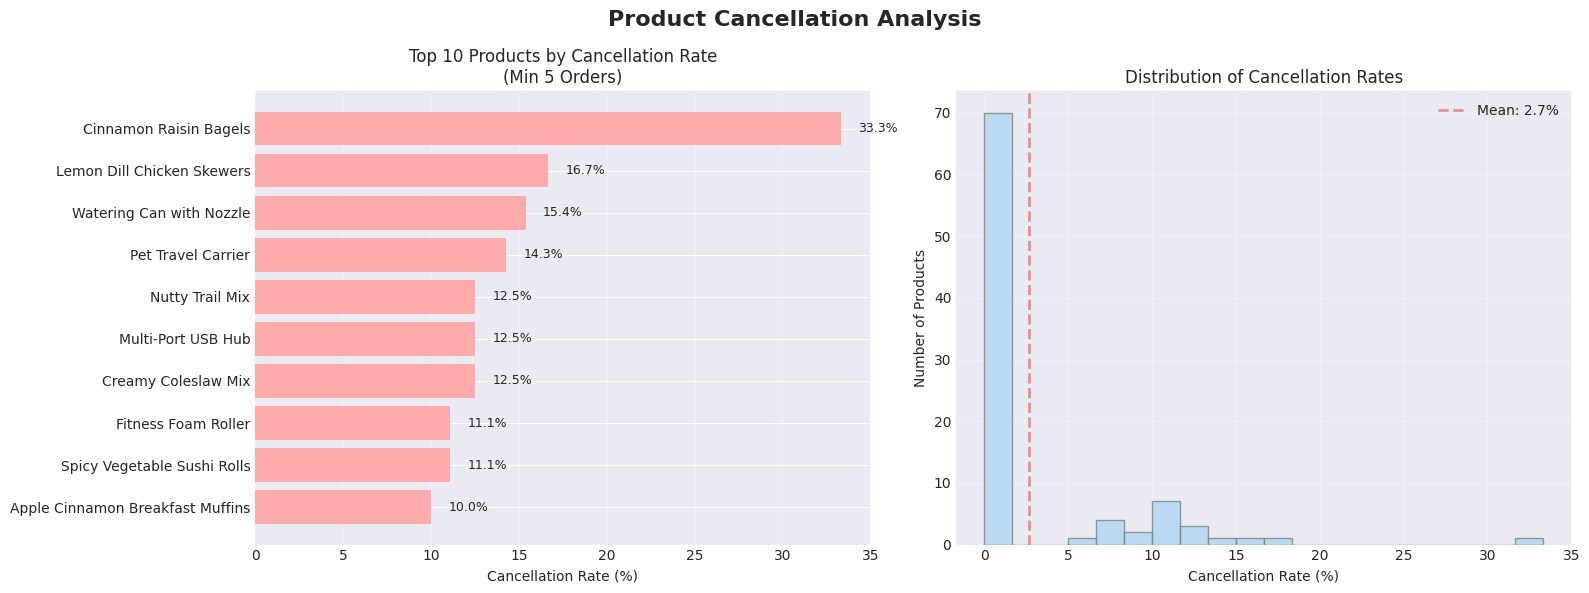


📊 Cancellation Summary:
Average Cancellation Rate: 2.67%
Median Cancellation Rate: 0.00%
Products with >20% cancellation rate: 1


In [0]:
import matplotlib.pyplot as plt

# Query top 10 products by return rate (with minimum order threshold)
top_return_rate = spark.sql("""
    SELECT 
        product_name, 
        return_rate,
        (cancelled_count + non_cancelled_count) as total_orders
    FROM cancelled_product_gold
    WHERE (cancelled_count + non_cancelled_count) >= 5  -- At least 5 orders
    ORDER BY return_rate DESC
    LIMIT 10
""").toPandas()

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Product Cancellation Analysis', fontsize=16, fontweight='bold')

# Bar chart for return rate with softer pastel color
ax1.barh(top_return_rate['product_name'], top_return_rate['return_rate'] * 100, color='#FFABAB')  # Soft pastel pink/red
ax1.set_xlabel('Cancellation Rate (%)')
ax1.set_title('Top 10 Products by Cancellation Rate\n(Min 5 Orders)')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

# Add percentage labels
for i, (idx, row) in enumerate(top_return_rate.iterrows()):
    ax1.text(row['return_rate'] * 100 + 1, i, f"{row['return_rate']*100:.1f}%", 
             va='center', fontsize=9)

# Distribution of return rates (histogram) with softer pastel blue
all_return_rates = spark.sql("""
    SELECT return_rate
    FROM cancelled_product_gold
    WHERE (cancelled_count + non_cancelled_count) >= 5
""").toPandas()

ax2.hist(all_return_rates['return_rate'] * 100, bins=20, color='#AED6F1', edgecolor='gray', alpha=0.8)  # Soft pastel blue
ax2.set_xlabel('Cancellation Rate (%)')
ax2.set_ylabel('Number of Products')
ax2.set_title('Distribution of Cancellation Rates')
ax2.axvline(all_return_rates['return_rate'].mean() * 100, color='#E88E8E', linestyle='--', 
            linewidth=2, label=f'Mean: {all_return_rates["return_rate"].mean()*100:.1f}%')  # Softer red for mean line
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Cancellation Summary:")
print(f"Average Cancellation Rate: {all_return_rates['return_rate'].mean()*100:.2f}%")
print(f"Median Cancellation Rate: {all_return_rates['return_rate'].median()*100:.2f}%")
print(f"Products with >20% cancellation rate: {len(all_return_rates[all_return_rates['return_rate'] > 0.2])}")

In [0]:
# Regional Sales Analysis (Gold Layer)
# Purpose: Aggregate sales by geographic regions and countries
#
# Tables Created:
#   1. sales_region_gold: Sales aggregated by major regions (APAC, EMEA, LATAM, North America)
#   2. sales_country_gold: Sales aggregated by individual countries
#
# Use Cases:
#   - Market performance comparison
#   - Expansion opportunity identification
#   - Regional sales trends
#   - Geographic heat maps for dashboards

# ===== 1. Sales by Region =====
spark.sql("""
CREATE OR REPLACE TABLE sales_region_gold AS
SELECT
  CASE 
    WHEN country IN ('US', 'CA', 'DO') THEN 'North America'
    WHEN country IN ('CO', 'PE', 'AR', 'VE', 'BR') THEN 'LATAM'
    WHEN country IN ('JP', 'CN', 'ID', 'TH', 'PH', 'KZ', 'MN') THEN 'APAC'
    WHEN country IN ('PT', 'NO', 'FR', 'PL', 'CV', 'CZ', 'RU', 'ES', 'SE', 'SI', 'HR', 'AM', 
                     'ZW', 'AF', 'NG', 'TN', 'CM', 'SS', 'ZM', 'MW') THEN 'EMEA'
    ELSE 'Other (null)'
  END AS region,
  SUM(order_silver.unified_amount) AS total_sales,
  COUNT(DISTINCT order_silver.order_id) AS order_count,
  COUNT(DISTINCT customer_silver.customer_id) AS customer_count
FROM order_silver
JOIN customer_silver
  ON order_silver.customer_id = customer_silver.customer_id
WHERE order_silver.order_status != 'cancelled'
GROUP BY region
""")

# ===== 2. Sales by Country =====
spark.sql("""
CREATE OR REPLACE TABLE sales_country_gold AS
SELECT
  country,
  SUM(order_silver.unified_amount) AS total_sales,
  COUNT(DISTINCT order_silver.order_id) AS order_count,
  COUNT(DISTINCT customer_silver.customer_id) AS customer_count
FROM order_silver
JOIN customer_silver
  ON order_silver.customer_id = customer_silver.customer_id
WHERE order_silver.order_status != 'cancelled'
GROUP BY country
""")

# Preview results
print("✅ Regional sales tables created successfully\n")
display(spark.sql("SELECT * FROM sales_region_gold ORDER BY total_sales DESC"))

✅ Regional sales tables created successfully



region,total_sales,order_count,customer_count
EMEA,78528.0931292401,136,30
APAC,78483.51983106007,175,34
Other (null),41671.327509600014,162,32
LATAM,13208.12363344001,48,11
North America,3676.46823284,23,5


In [0]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ===== Geographic Sales Visualization =====

# Query country-level sales data
df_country = spark.sql("""
    SELECT country, total_sales, order_count, customer_count 
    FROM sales_country_gold
    ORDER BY total_sales DESC
""").toPandas()

# Map country codes to full names for Plotly
country_code_to_name = {
    'FR': 'France', 'PH': 'Philippines', 'CA': 'Canada', 'SS': 'South Sudan', 'MN': 'Mongolia',
    'ID': 'Indonesia', 'US': 'United States', 'PT': 'Portugal', 'NG': 'Nigeria', 'SI': 'Slovenia',
    'ZW': 'Zimbabwe', 'PL': 'Poland', 'AM': 'Armenia', 'CO': 'Colombia', 'AR': 'Argentina',
    'HR': 'Croatia', 'MW': 'Malawi', 'CZ': 'Czech Republic', 'RU': 'Russia', 'JP': 'Japan',
    'CV': 'Cape Verde', 'CN': 'China', 'TN': 'Tunisia', 'DO': 'Dominican Republic', 'TH': 'Thailand',
    'KZ': 'Kazakhstan', 'BR': 'Brazil', 'NO': 'Norway', 'CM': 'Cameroon', 'AF': 'Afghanistan',
    'ES': 'Spain', 'PE': 'Peru', 'ZM': 'Zambia', 'SE': 'Sweden'
}

df_country['country_name'] = df_country['country'].map(country_code_to_name)
df_country_valid = df_country[df_country['country_name'].notnull()]

# Create choropleth map with softer color palette
fig = px.choropleth(
    df_country_valid,
    locations='country_name',
    locationmode='country names',
    color='total_sales',
    hover_name='country_name',
    hover_data={'total_sales': ':$,.0f', 'order_count': True, 'customer_count': True, 'country_name': False},
    color_continuous_scale='Purp',  # Softer purple palette instead of bright Viridis
    projection='natural earth',
    title='Global Sales Distribution by Country',
    labels={'total_sales': 'Total Sales ($)'}
)

fig.update_layout(
    height=600,
    geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth')
)

fig.show()

# Display top 10 countries table
print("\n🌍 Top 10 Countries by Sales:\n")
display(df_country_valid[['country', 'country_name', 'total_sales', 'order_count', 'customer_count']].head(10))


🌍 Top 10 Countries by Sales:



country,country_name,total_sales,order_count,customer_count
CN,China,30359.890557430033,74,16
PT,Portugal,20999.278610479996,31,6
ID,Indonesia,20681.558804870016,39,8
RU,Russia,17621.1833476,24,4
TH,Thailand,14238.95051397,24,4
CZ,Czech Republic,10730.585628779996,12,3
PL,Poland,10516.192623689998,18,3
PH,Philippines,9214.898331389999,36,7
AR,Argentina,6188.2604139999985,14,3
ZW,Zimbabwe,4691.80320932,6,1


In [0]:
# Data Quality Checks
# Quick validation queries to understand dataset characteristics

print("✅ Data Quality Summary\n")
print("=" * 60)

# 1. Geographic Coverage
print("\n1️⃣ GEOGRAPHIC COVERAGE")
print("-" * 60)
countries = spark.sql("SELECT DISTINCT country FROM sales_country_gold ORDER BY country").collect()
print(f"Total Countries: {len(countries)}")
print(f"Countries: {', '.join([row['country'] for row in countries if row['country'] is not None])}\n")

# 2. Date Range
print("\n2️⃣ DATA TIME RANGE")
print("-" * 60)
date_range = spark.sql("""
    SELECT 
        MIN(order_date) as oldest_order_date,
        MAX(order_date) as newest_order_date,
        DATEDIFF(MAX(order_date), MIN(order_date)) as days_span
    FROM orders_bronze
""").collect()[0]
print(f"Oldest Order: {date_range['oldest_order_date']}")
print(f"Newest Order: {date_range['newest_order_date']}")
print(f"Time Span: {date_range['days_span']} days\n")

# 3. Missing Country for Customer
print("\n3️⃣ MISSING COUNTRY FOR CUSTOMER")
print("-" * 60)
missing_country_count = spark.sql("""
    SELECT COUNT(*) AS cnt
    FROM customer_silver
    WHERE country IS NULL OR country = ''
""").collect()[0]['cnt']
total_customers = spark.sql("SELECT COUNT(*) AS cnt FROM customer_silver").collect()[0]['cnt']
missing_country_pct = (missing_country_count / total_customers) * 100 if total_customers else 0
print(f"Customers missing country: {missing_country_count} ({missing_country_pct:.2f}%)\n")

# 4. Conflicting Active Status
print("\n4️⃣ CONFLICTING ACTIVE STATUS")
print("-" * 60)
conflicting_status_count = spark.sql("""
    SELECT COUNT(*) AS cnt
    FROM customer_silver
    WHERE active_status_is_correct = false
""").collect()[0]['cnt']
conflicting_status_pct = (conflicting_status_count / total_customers) * 100 if total_customers else 0
print(f"Customers with conflicting active status: {conflicting_status_count} ({conflicting_status_pct:.2f}%)\n")

✅ Data Quality Summary


1️⃣ GEOGRAPHIC COVERAGE
------------------------------------------------------------
Total Countries: 35
Countries: AF, AM, AR, BR, CA, CM, CN, CO, CV, CZ, DO, ES, FR, HR, ID, JP, KZ, MN, MW, NG, NO, PE, PH, PL, PT, RU, SE, SI, SS, TH, TN, US, ZM, ZW


2️⃣ DATA TIME RANGE
------------------------------------------------------------
Oldest Order: 2024-12-30 01:11:43
Newest Order: 2025-12-29 22:02:17
Time Span: 364 days


3️⃣ MISSING COUNTRY FOR CUSTOMER
------------------------------------------------------------
Customers missing country: 33 (25.78%)


4️⃣ CONFLICTING ACTIVE STATUS
------------------------------------------------------------
Customers with conflicting active status: 35 (27.34%)



---

## 🔍 Data Exploration & Quality Checks

**Purpose**: Quick queries to validate data completeness and understand dataset characteristics.

These cells can be removed or collapsed in production.

---

## 🎯 Pipeline Summary & Next Steps

### ✅ Completed

This notebook successfully implements a **3-layer medallion architecture** for NovaFinds e-commerce data:

**🥉 Bronze Layer** 
* 10 raw tables ingested from CSV files
* Preserved `_rescued_data` for data quality monitoring

**🥈 Silver Layer**  
* 4 cleaned and enriched tables
* Business logic applied (filtering, validation, joins)
* Analytics-ready datasets

**🥇 Gold Layer**  
* 4 aggregated business metrics tables
* Product profitability analysis
* Cancellation/return rate analysis
* Regional sales analysis

### 🚀 Next Steps

1. **Automation**: Schedule this notebook to run daily/hourly using Databricks Jobs
2. **Data Quality**: Add comprehensive data quality checks and alerts
3. **Performance**: Add table partitioning and Z-ordering for large tables
4. **Dashboards**: Connect gold tables to BI tools (Tableau, Power BI, Lakeview dashboards)
5. **Incremental Processing**: Implement incremental loads for bronze layer (instead of full refresh)
6. **Documentation**: Create data dictionary for all tables and columns
7. **Testing**: Add unit tests for data transformations

### 📚 Resources

* [Databricks Medallion Architecture](https://docs.databricks.com/lakehouse/medallion.html)
* [Delta Live Tables](https://docs.databricks.com/delta-live-tables/index.html) - Consider migrating to DLT for production
* [Unity Catalog](https://docs.databricks.com/data-governance/unity-catalog/index.html) - For data governance